### Import libraries for data analysis

In [1]:
import pandas as pd 

In [5]:
data = pd.read_csv('../data/hospital_data.csv') # Get data from data folder one step up.

### Exploratory Data Analysis
We will explore the native functions and the hospital dataset.


In [ ]:
data.head(5) 

,Date,Medication Revenue,Lab Cost,Consultation Revenue,Doctor Type,Financial Class,Patient Type,Entry Time,Post-Consultation Time,Completion Time,Doctor,Patient ID
0,11/4/2019 0:00,"$1,183.22",$10.00,$20.17,ANCHOR,HMO,OUTPATIENT,8:35:45,9:17:54,9:29:46,DR05350C4,C10001
1,11/6/2019 0:00,$738.48,$-,$15.00,ANCHOR,INSURANCE,OUTPATIENT,19:19:16,21:02:36,21:24:07,DR09451Z4,C10002
2,11/2/2019 0:00,$660.00,$-,$21.17,ANCHOR,HMO,OUTPATIENT,10:46:52,11:56:25,12:06:28,DR17400I4,C10003
3,11/6/2019 0:00,$600.00,$-,$-,ANCHOR,MEDICARE,OUTPATIENT,9:38:34,10:55:50,10:58:02,DR09451Z4,C10004
4,11/1/2019 0:00,$591.60,$-,$12.00,ANCHOR,INSURANCE,OUTPATIENT,11:16:21,12:06:49,12:06:54,DR15154H4,C10005


In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Date                    29999 non-null  str  
 1    Medication Revenue     29999 non-null  str  
 2     Lab Cost              29999 non-null  str  
 3    Consultation Revenue   29999 non-null  str  
 4   Doctor Type             29999 non-null  str  
 5   Financial Class         29999 non-null  str  
 6   Patient Type            29999 non-null  str  
 7   Entry Time              29999 non-null  str  
 8   Post-Consultation Time  29999 non-null  str  
 9   Completion Time         29999 non-null  str  
 10  Doctor                  29999 non-null  str  
 11  Patient ID              29999 non-null  str  
dtypes: str(12)
memory usage: 2.7 MB


In [12]:
#clean the whitespaces in the column headings using Strip() function.
data.columns = data.columns.str.strip()
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Date                    29999 non-null  str  
 1   Medication Revenue      29999 non-null  str  
 2   Lab Cost                29999 non-null  str  
 3   Consultation Revenue    29999 non-null  str  
 4   Doctor Type             29999 non-null  str  
 5   Financial Class         29999 non-null  str  
 6   Patient Type            29999 non-null  str  
 7   Entry Time              29999 non-null  str  
 8   Post-Consultation Time  29999 non-null  str  
 9   Completion Time         29999 non-null  str  
 10  Doctor                  29999 non-null  str  
 11  Patient ID              29999 non-null  str  
dtypes: str(12)
memory usage: 2.7 MB


In [13]:
data.head(5)

,Date,Medication Revenue,Lab Cost,Consultation Revenue,Doctor Type,Financial Class,Patient Type,Entry Time,Post-Consultation Time,Completion Time,Doctor,Patient ID
0,11/4/2019 0:00,"$1,183.22",$10.00,$20.17,ANCHOR,HMO,OUTPATIENT,8:35:45,9:17:54,9:29:46,DR05350C4,C10001
1,11/6/2019 0:00,$738.48,$-,$15.00,ANCHOR,INSURANCE,OUTPATIENT,19:19:16,21:02:36,21:24:07,DR09451Z4,C10002
2,11/2/2019 0:00,$660.00,$-,$21.17,ANCHOR,HMO,OUTPATIENT,10:46:52,11:56:25,12:06:28,DR17400I4,C10003
3,11/6/2019 0:00,$600.00,$-,$-,ANCHOR,MEDICARE,OUTPATIENT,9:38:34,10:55:50,10:58:02,DR09451Z4,C10004
4,11/1/2019 0:00,$591.60,$-,$12.00,ANCHOR,INSURANCE,OUTPATIENT,11:16:21,12:06:49,12:06:54,DR15154H4,C10005


In [ ]:
#Data cleaning function

def clean_text(x):
    x = x.replace('$', '')
    x = x.replace('-', '')
    x = x.replace(',', '')
    x = x.replace(' ', '')
    x = pd.to_numeric(x)
    return x

In [ ]:
#Apply clean_text function to relevant columns

data['Medication Revenue']=data['Medication Revenue'].apply(clean_text)
data['Lab Cost'] = data['Lab Cost'].apply(clean_text)
data['Consultation Revenue'] = data['Consultation Revenue'].apply(clean_text)

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Date                    29999 non-null  str    
 1   Medication Revenue      18062 non-null  float64
 2   Lab Cost                1433 non-null   float64
 3   Consultation Revenue    24423 non-null  float64
 4   Doctor Type             29999 non-null  str    
 5   Financial Class         29999 non-null  str    
 6   Patient Type            29999 non-null  str    
 7   Entry Time              29999 non-null  str    
 8   Post-Consultation Time  29999 non-null  str    
 9   Completion Time         29999 non-null  str    
 10  Doctor                  29999 non-null  str    
 11  Patient ID              29999 non-null  str    
dtypes: float64(3), str(9)
memory usage: 2.7 MB


In [ ]:
data = data.fillna(0) #fill in to replace NaN 

In [ ]:
#Feature engineer a total revenue column to enrich analysis
data['Total Revenue'] = data['Medication Revenue']+data['Consultation Revenue']


In [22]:
data.head(4)

,Date,Medication Revenue,Lab Cost,Consultation Revenue,Doctor Type,Financial Class,Patient Type,Entry Time,Post-Consultation Time,Completion Time,Doctor,Patient ID,Total Revenue
0,11/4/2019 0:00,1183.22,10.0,20.17,ANCHOR,HMO,OUTPATIENT,8:35:45,9:17:54,9:29:46,DR05350C4,C10001,1203.39
1,11/6/2019 0:00,738.48,0.0,15.00,ANCHOR,INSURANCE,OUTPATIENT,19:19:16,21:02:36,21:24:07,DR09451Z4,C10002,753.48
2,11/2/2019 0:00,660.00,0.0,21.17,ANCHOR,HMO,OUTPATIENT,10:46:52,11:56:25,12:06:28,DR17400I4,C10003,681.17
3,11/6/2019 0:00,600.00,0.0,0.00,ANCHOR,MEDICARE,OUTPATIENT,9:38:34,10:55:50,10:58:02,DR09451Z4,C10004,600.00


In [24]:
data['Date'] = pd.to_datetime(data['Date'])
data['Day of Week'] = data['Date'].dt.dayofweek
data['Day Name'] = data['Date'].dt.strftime('%A')
data.head(5)

,Date,Medication Revenue,Lab Cost,Consultation Revenue,Doctor Type,Financial Class,Patient Type,Entry Time,Post-Consultation Time,Completion Time,Doctor,Patient ID,Total Revenue,date,Day of Week,Day Name
0,2019-11-04,1183.22,10.0,20.17,ANCHOR,HMO,OUTPATIENT,8:35:45,9:17:54,9:29:46,DR05350C4,C10001,1203.39,2019-11-04,0,Monday
1,2019-11-06,738.48,0.0,15.00,ANCHOR,INSURANCE,OUTPATIENT,19:19:16,21:02:36,21:24:07,DR09451Z4,C10002,753.48,2019-11-06,2,Wednesday
2,2019-11-02,660.00,0.0,21.17,ANCHOR,HMO,OUTPATIENT,10:46:52,11:56:25,12:06:28,DR17400I4,C10003,681.17,2019-11-02,5,Saturday
3,2019-11-06,600.00,0.0,0.00,ANCHOR,MEDICARE,OUTPATIENT,9:38:34,10:55:50,10:58:02,DR09451Z4,C10004,600.00,2019-11-06,2,Wednesday
4,2019-11-01,591.60,0.0,12.00,ANCHOR,INSURANCE,OUTPATIENT,11:16:21,12:06:49,12:06:54,DR15154H4,C10005,603.60,2019-11-01,4,Friday


In [29]:
#Create function to get hour

def get_hour(y):
    y=pd.to_datetime(y)
    y=y.hour
    return y

In [30]:
# Create hours for relevant columns

data['Entry Hour']= data['Entry Time'].apply(get_hour)
data['Post Consultation Hour']= data['Post-Consultation Time'].apply(get_hour)
data['Completion Hour']= data['Completion Time'].apply(get_hour)

data.head()

,Date,Medication Revenue,Lab Cost,Consultation Revenue,Doctor Type,Financial Class,Patient Type,Entry Time,Post-Consultation Time,Completion Time,Doctor,Patient ID,Total Revenue,date,Day of Week,Day Name,Entry Hour,Post Consultation Hour,Completion Hour
0,2019-11-04,1183.22,10.0,20.17,ANCHOR,HMO,OUTPATIENT,8:35:45,9:17:54,9:29:46,DR05350C4,C10001,1203.39,2019-11-04,0,Monday,8,9,9
1,2019-11-06,738.48,0.0,15.00,ANCHOR,INSURANCE,OUTPATIENT,19:19:16,21:02:36,21:24:07,DR09451Z4,C10002,753.48,2019-11-06,2,Wednesday,19,21,21
2,2019-11-02,660.00,0.0,21.17,ANCHOR,HMO,OUTPATIENT,10:46:52,11:56:25,12:06:28,DR17400I4,C10003,681.17,2019-11-02,5,Saturday,10,11,12
3,2019-11-06,600.00,0.0,0.00,ANCHOR,MEDICARE,OUTPATIENT,9:38:34,10:55:50,10:58:02,DR09451Z4,C10004,600.00,2019-11-06,2,Wednesday,9,10,10
4,2019-11-01,591.60,0.0,12.00,ANCHOR,INSURANCE,OUTPATIENT,11:16:21,12:06:49,12:06:54,DR15154H4,C10005,603.60,2019-11-01,4,Friday,11,12,12


### Visualise data to show heatmap
The organisation wants to see a heatmap of when the clinic receives most patients and revenue.

In [33]:
#import visualisatuion libraries

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('dark_background')

In [26]:
data.groupby('Day Name')['Total Revenue'].sum().sort_values()

Day Name
Thursday      90496.21
Sunday       108721.51
Saturday     117068.50
Wednesday    144104.03
Friday       166583.13
Tuesday      196997.27
Monday       253106.12
Name: Total Revenue, dtype: float64

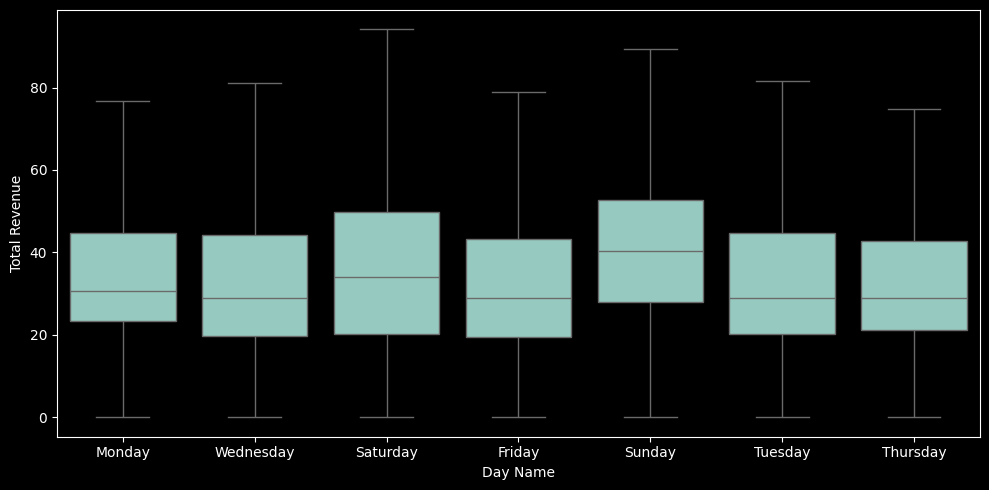

In [34]:
# Visualise using boxplot

plt.figure(figsize=(10,5))
sns.boxplot(data=data, x='Day Name', y='Total Revenue', showfliers=False)
plt.tight_layout()

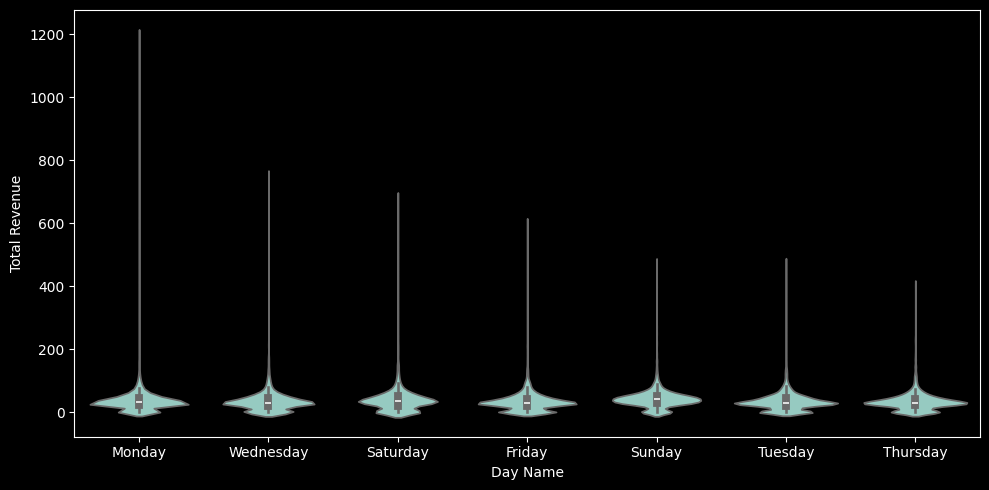

In [35]:
plt.figure(figsize=(10,5))
sns.violinplot(data=data, x='Day Name', y='Total Revenue')
plt.tight_layout()

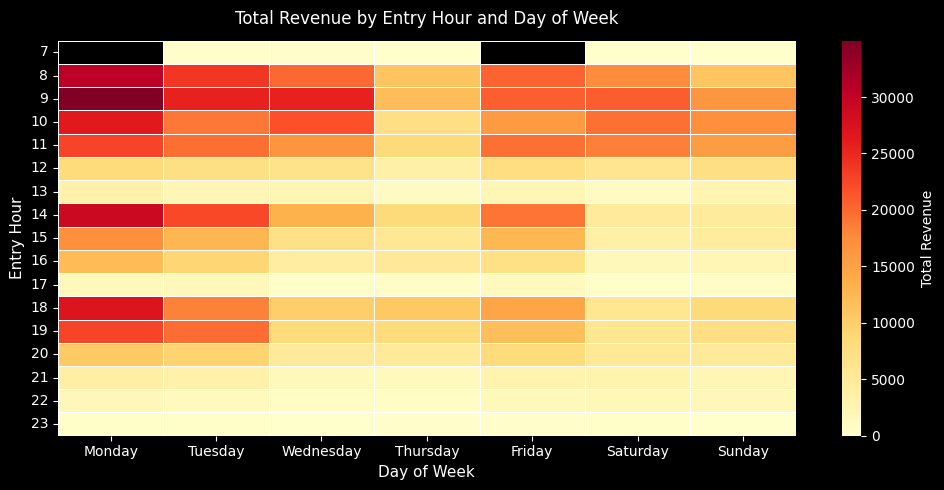

In [43]:
# To create a heatmap, create a pivot table first.

# Define correct day order
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

pivot = pd.pivot_table(data, index='Entry Hour', columns= 'Day Name', values= 'Total Revenue', aggfunc='sum')

#Reorder days sequence
pivot = pivot[day_order]

#Plot heatmap
plt.figure(figsize=(10,5))
sns.heatmap(pivot,
            cmap= 'YlOrRd',
            fmt='.0f',
            linewidths=0.5,
            cbar_kws={'label': 'Total Revenue'})

plt.title('Total Revenue by Entry Hour and Day of Week', fontsize=12, pad=12)
plt.xlabel('Day of Week', fontsize=11)
plt.ylabel('Entry Hour', fontsize=11)
plt.yticks(rotation=0)       # un-rotate hour labels
plt.tight_layout()
plt.show()

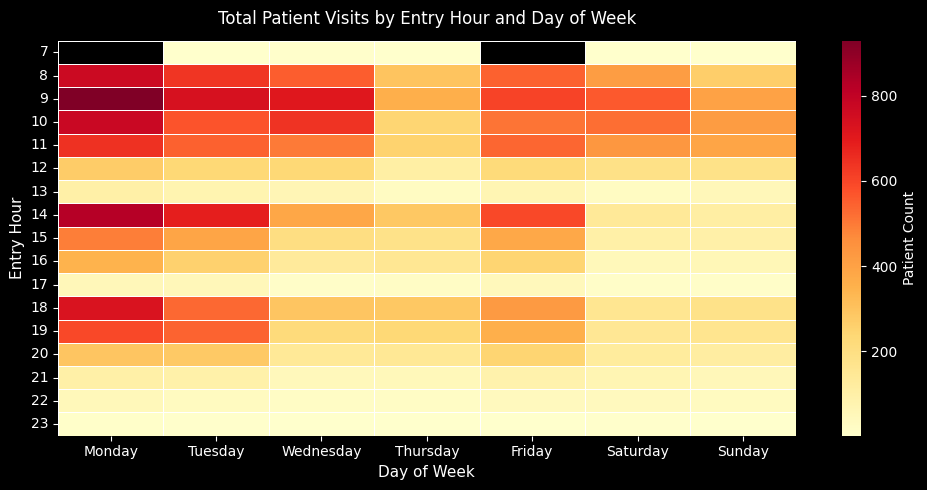

In [44]:

# Define correct day order
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

pivot = pd.pivot_table(data, index='Entry Hour', columns= 'Day Name', values= 'Patient ID', aggfunc='count')

#Reorder days sequence
pivot = pivot[day_order]

#Plot heatmap
plt.figure(figsize=(10,5))
sns.heatmap(pivot,
            cmap= 'YlOrRd',
            fmt='.0f',
            linewidths=0.5,
            cbar_kws={'label': 'Patient Count'})

plt.title('Total Patient Visits by Entry Hour and Day of Week', fontsize=12, pad=12)
plt.xlabel('Day of Week', fontsize=11)
plt.ylabel('Entry Hour', fontsize=11)
plt.yticks(rotation=0)       # un-rotate hour labels
plt.tight_layout()
plt.show()

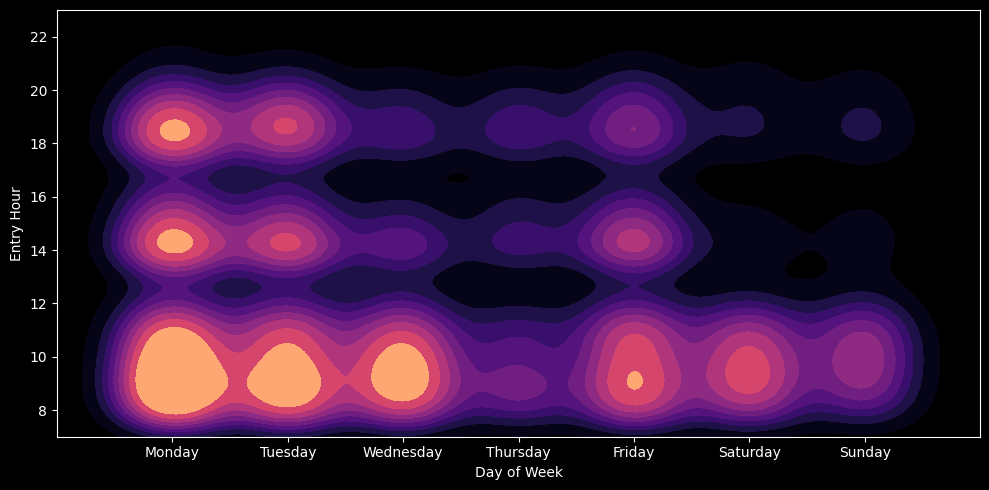

In [49]:
#Kdeplot can be used as well to plot heatmap

plt.figure(figsize=(10,5))
plt.xlim(-1, 7)
plt.ylim(7, 23)
plt.xticks([0,1,2,3,4,5,6],['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
sns.kdeplot(x=data['Day of Week'], y=data['Entry Hour'], fill=True,cmap='magma')
plt.tight_layout()

### Export cleaned dataset to Power BI

In [50]:
data.to_csv('hospital_data_cleaned.csv')